In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn
import os
import sys


import percolating_cluster
import monopole_data

import wrappings
sys.path.append(os.path.join(os.path.dirname(
    os.path.abspath(''))))
import common.plots as plots
import common.scaler as scaler

In [2]:
def read_functional(paths):
    df = []
    for path in paths:
        if 'chain' in path:
            chain = path['chain']
        else:
            chain = '/'
        if 'padding' in path:
            padding = path['padding']
        else:
            padding = 4
        for i in range(path['conf_range'][0], path['conf_range'][1] + 1):
            data_path = path['path'] + f'_{i:0{padding}}'
            if(os.path.isfile(data_path)):
                df1 = pd.read_csv(data_path)
                if not df1.empty:
                    df.append(df1)
                    df[-1]['conf'] = chain + f'-{i}'
                    if 'parameters' in path:
                            for key, val in path['parameters'].items():
                                df[-1][key] = val
    return pd.concat(df)

def fill_funcational_max(df, groupby_keys):
    df2 = []
    copy_num = df.groupby(['copy']).ngroups
    for copy_max in range(copy_num):
        df1 = df[df['copy'] <= copy_max]
        df1 = df1.groupby(groupby_keys + ['conf'])['functional'].max().reset_index(level=groupby_keys + ['conf'])
        df2.append(df1.groupby(groupby_keys)['functional']\
                  .agg([('functional', 'mean'), ('std', lambda x: np.std(x, ddof=1)/math.sqrt(np.size(x)))]).reset_index(level=groupby_keys))
        df2[-1]['copy'] = copy_max
    return pd.concat(df2).reset_index(drop=True)

    copy  functional     conf  beta     size  steps
0      0    0.834026      /-1   6.2     32^4     20
1      1    0.833657      /-1   6.2     32^4     20
2      2    0.833994      /-1   6.2     32^4     20
3      3    0.833925      /-1   6.2     32^4     20
4      4    0.834051      /-1   6.2     32^4     20
..   ...         ...      ...   ...      ...    ...
1      1    0.834135  s2-2118   6.2  32^3x64      3
2      2    0.834194  s2-2118   6.2  32^3x64      3
0      0    0.834079  s2-2119   6.2  32^3x64      3
1      1    0.834065  s2-2119   6.2  32^3x64      3
2      2    0.834071  s2-2119   6.2  32^3x64      3

[88941 rows x 6 columns]
    steps  functional       std  copy
0       3    0.833991  0.000002     0
1      20    0.833987  0.000003     0
2       3    0.834041  0.000002     1
3      20    0.834054  0.000003     1
4       3    0.834065  0.000002     2
5      20    0.834085  0.000002     2
6       3    0.834065  0.000002     3
7      20    0.834107  0.000002     3
8       

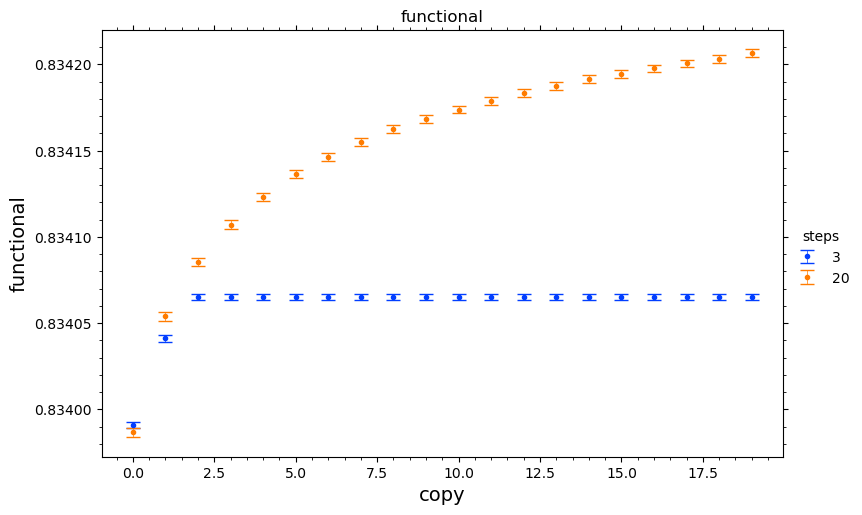

In [5]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.2/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.2, 'size': '32^4', 'steps': 20}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^3x64/beta6.2/steps_0/copies=3/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.2, 'size': '32^3x64', 'steps': 3}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^3x64/beta6.2/steps_0/copies=3/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.2, 'size': '32^3x64', 'steps': 3}, 'chain': 's2'}]
df_func = read_functional(paths_functional)
print(df_func)
df_func = fill_funcational_max(df_func, ['steps'])
print(df_func)
plots.make_plot(df_func, 'copy', 'functional', 'steps', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.2', True, err='std')

    copy  functional    conf  beta  size  steps
0      0    0.839309     /-1   6.3  36^4     20
1      1    0.839464     /-1   6.3  36^4     20
2      2    0.839329     /-1   6.3  36^4     20
3      3    0.839290     /-1   6.3  36^4     20
4      4    0.839063     /-1   6.3  36^4     20
..   ...         ...     ...   ...   ...    ...
0      0    0.839795  /-2131   6.3  36^4      1
0      0    0.839319  /-2132   6.3  36^4      1
0      0    0.838958  /-2133   6.3  36^4      1
0      0    0.839185  /-2134   6.3  36^4      1
0      0    0.839499  /-2135   6.3  36^4      1

[44815 rows x 6 columns]
    steps  functional       std  copy
0       1    0.839299  0.000003     0
1      20    0.839295  0.000003     0
2       1    0.839299  0.000003     1
3      20    0.839356  0.000003     1
4       1    0.839299  0.000003     2
5      20    0.839386  0.000003     2
6       1    0.839299  0.000003     3
7      20    0.839404  0.000003     3
8       1    0.839299  0.000003     4
9      20    0.839

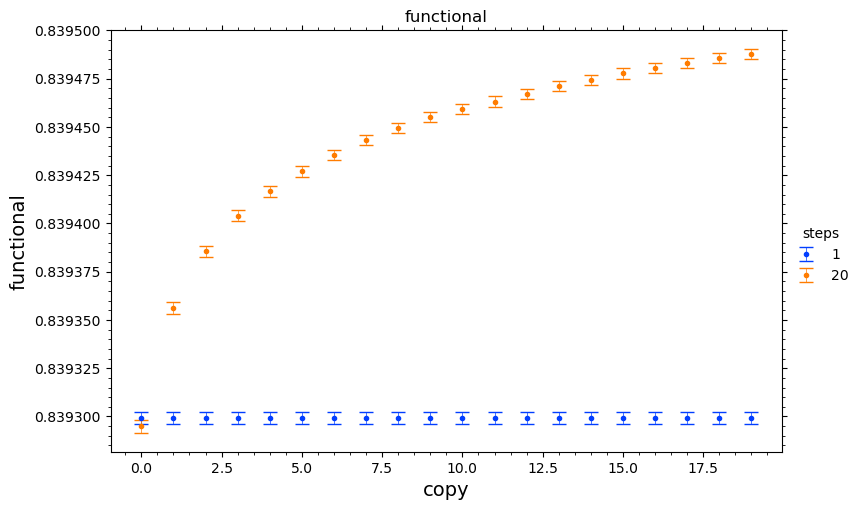

In [3]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.3/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.3, 'size': '36^4', 'steps': 20}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.3/steps_0/copies=1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.3, 'size': '36^4', 'steps': 1}}]
df_func = read_functional(paths_functional)
print(df_func)
df_func = fill_funcational_max(df_func, ['steps'])
print(df_func)
plots.make_plot(df_func, 'copy', 'functional', 'steps', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.0 24^4', True, err='std')

    copy  functional    conf  beta  size  steps
0      0    0.821351  /-1001   6.0  16^4      0
1      1    0.821456  /-1001   6.0  16^4      0
2      2    0.822085  /-1001   6.0  16^4      0
3      3    0.821332  /-1001   6.0  16^4      0
4      4    0.822280  /-1001   6.0  16^4      0
..   ...         ...     ...   ...   ...    ...
95    95    0.821569  s0-500   6.0    32      0
96    96    0.821482  s0-500   6.0    32      0
97    97    0.821684  s0-500   6.0    32      0
98    98    0.821785  s0-500   6.0    32      0
99    99    0.821655  s0-500   6.0    32      0

[284200 rows x 6 columns]
     size  functional       std  copy
0    16^4    0.821440  0.000017     0
1    24^4    0.821500  0.000009     0
2      32    0.821502  0.000007     0
3    16^4    0.821659  0.000016     1
4    24^4    0.821599  0.000008     1
..    ...         ...       ...   ...
295  24^4    0.821918  0.000008    98
296    32    0.821747  0.000006    98
297  16^4    0.822304  0.000015    99
298  24^4    0.82

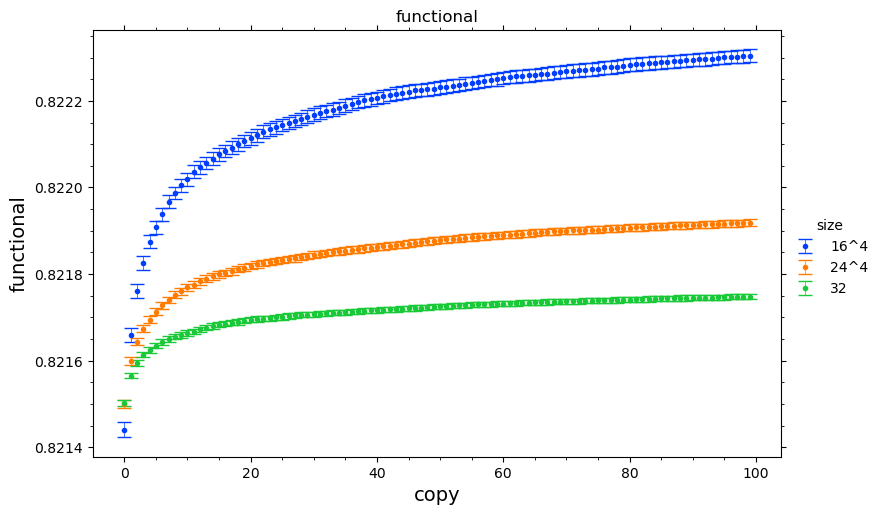

In [3]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/16^4/beta6.0/steps_0/copies=100/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '16^4', 'steps': 0}, 'padding': 5},
                    {'path': '../../data/mag/functional/su3/gluodynamics/24^4/beta6.0/steps_0/copies=100/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '24^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=100/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32', 'steps': 0}, 'chain': 's0'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=100/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32', 'steps': 0}, 'chain': 's1'}]
df_func = read_functional(paths_functional)
print(df_func)
df_func = fill_funcational_max(df_func, ['size'])
print(df_func)
plots.make_plot(df_func, 'copy', 'functional', 'size', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.0 24^4', True, err='std')

    copy  functional     conf  beta  size  steps
0    0.0    0.821456   /-1001   6.0  16^4      0
1    1.0    0.821840   /-1001   6.0  16^4      0
2    2.0    0.821687   /-1001   6.0  16^4      0
3    3.0    0.821151   /-1001   6.0  16^4      0
4    4.0    0.822155   /-1001   6.0  16^4      0
..   ...         ...      ...   ...   ...    ...
15  15.0    0.821501  s1-2000   6.0    32      0
16  16.0    0.821322  s1-2000   6.0    32      0
17  17.0    0.821432  s1-2000   6.0    32      0
18  18.0    0.821406  s1-2000   6.0    32      0
19  19.0    0.821384  s1-2000   6.0    32      0

[205155 rows x 6 columns]
    size  functional       std  copy
0   16^4    0.821445  0.000017     0
1   24^4    0.821495  0.000004     0
2     32    0.821503  0.000003     0
3   16^4    0.821652  0.000016     1
4   24^4    0.821598  0.000004     1
5     32    0.821557  0.000002     1
6   16^4    0.821760  0.000016     2
7   24^4    0.821649  0.000004     2
8     32    0.821585  0.000002     2
9   16^4    0.8

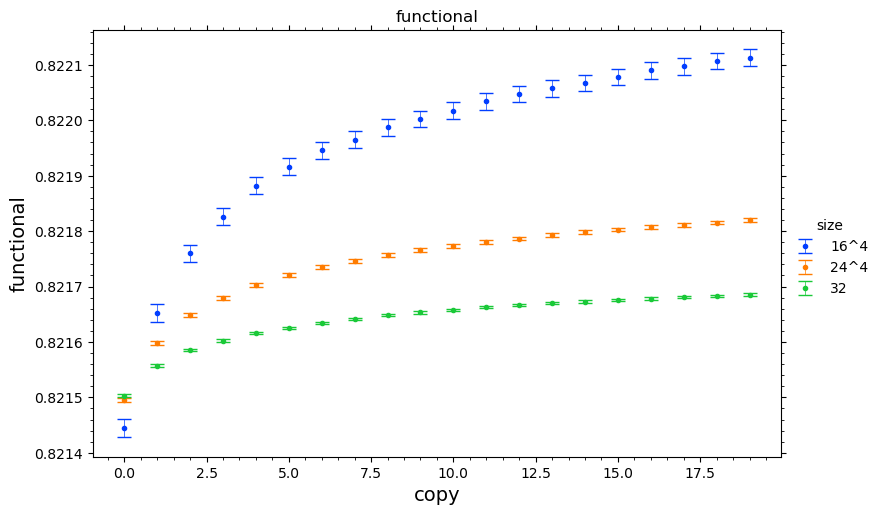

In [6]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/16^4/beta6.0/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '16^4', 'steps': 0}, 'padding': 5},
                    {'path': '../../data/mag/functional/su3/gluodynamics/24^4/beta6.0/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '24^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=20/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32', 'steps': 0}, 'chain': 's0'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=20/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32', 'steps': 0}, 'chain': 's1'}]
df_func = read_functional(paths_functional)
print(df_func)
df_func = fill_funcational_max(df_func, ['size'])
print(df_func)
plots.make_plot(df_func, 'copy', 'functional', 'size', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.0 24^4', True, err='std')

    copy  functional     conf  beta  size  steps
0    0.0    0.821522     s0-2   6.0    32      0
1    1.0    0.821684     s0-2   6.0    32      0
2    2.0    0.821560     s0-2   6.0    32      0
3    3.0    0.821363     s0-2   6.0    32      0
4    4.0    0.821350     s0-2   6.0    32      0
..   ...         ...      ...   ...   ...    ...
15  15.0    0.821501  s1-2000   6.0    32      0
16  16.0    0.821322  s1-2000   6.0    32      0
17  17.0    0.821432  s1-2000   6.0    32      0
18  18.0    0.821406  s1-2000   6.0    32      0
19  19.0    0.821384  s1-2000   6.0    32      0

[78295 rows x 6 columns]
    beta  functional       std  copy
0    6.0    0.821503  0.000003     0
1    6.0    0.821557  0.000002     1
2    6.0    0.821585  0.000002     2
3    6.0    0.821603  0.000002     3
4    6.0    0.821616  0.000002     4
5    6.0    0.821626  0.000002     5
6    6.0    0.821634  0.000002     6
7    6.0    0.821642  0.000002     7
8    6.0    0.821648  0.000002     8
9    6.0    0.82

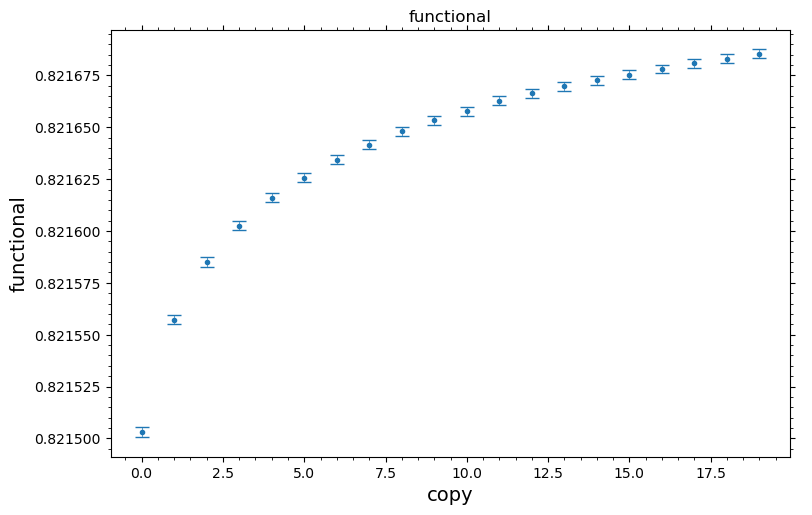

In [12]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=20/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': 32, 'steps': 0}, 'chain': 's0'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=20/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': 32, 'steps': 0}, 'chain': 's1'}]
df_func = read_functional(paths_functional)
print(df_func)
df_func = fill_funcational_max(df_func, ['beta'])
print(df_func)
plots.make_plot(df_func, 'copy', 'functional', None, 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.0 24^4', True, err='std')

    copy  functional    conf  beta  size  steps
0      0    0.828314     /-1   6.1  28^4      0
1      1    0.828128     /-1   6.1  28^4      0
2      2    0.828214     /-1   6.1  28^4      0
3      3    0.828243     /-1   6.1  28^4      0
4      4    0.828453     /-1   6.1  28^4      0
..   ...         ...     ...   ...   ...    ...
15    15    0.828160  /-5000   6.1  28^4      0
16    16    0.828148  /-5000   6.1  28^4      0
17    17    0.828097  /-5000   6.1  28^4      0
18    18    0.828120  /-5000   6.1  28^4      0
19    19    0.828012  /-5000   6.1  28^4      0

[100000 rows x 6 columns]
    size  functional       std  copy
0   28^4    0.828110  0.000003     0
1   28^4    0.828191  0.000003     1
2   28^4    0.828232  0.000003     2
3   28^4    0.828258  0.000003     3
4   28^4    0.828277  0.000003     4
5   28^4    0.828290  0.000003     5
6   28^4    0.828302  0.000003     6
7   28^4    0.828312  0.000003     7
8   28^4    0.828321  0.000003     8
9   28^4    0.828329  0.000

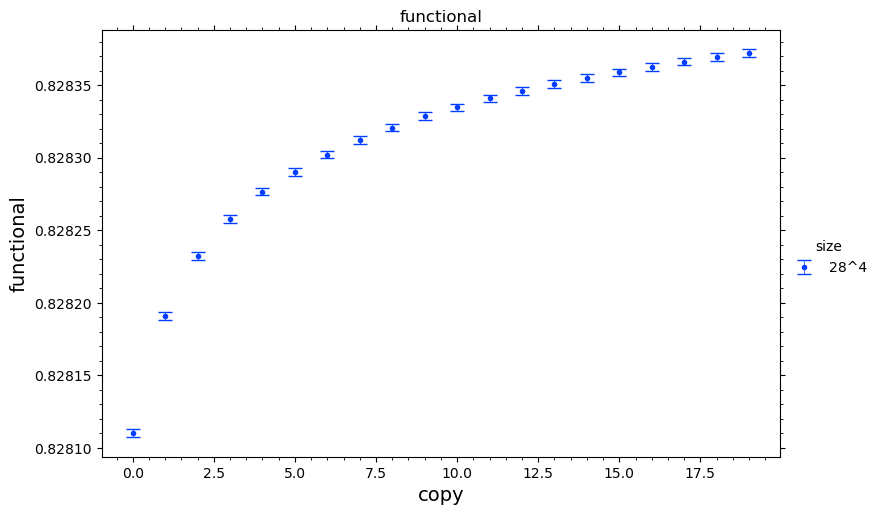

In [8]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/28^4/beta6.1/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.1, 'size': '28^4', 'steps': 0}}]
df_func = read_functional(paths_functional)
print(df_func)
df_func = fill_funcational_max(df_func, ['size'])
print(df_func)
plots.make_plot(df_func, 'copy', 'functional', 'size', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.0 24^4', True, err='std')

    copy  functional    conf  beta  size  steps
0      0    0.834026     /-1   6.2  32^4      0
1      1    0.833657     /-1   6.2  32^4      0
2      2    0.833994     /-1   6.2  32^4      0
3      3    0.833925     /-1   6.2  32^4      0
4      4    0.834051     /-1   6.2  32^4      0
..   ...         ...     ...   ...   ...    ...
15    15    0.833495  /-3813   6.2  32^4      0
16    16    0.833842  /-3813   6.2  32^4      0
17    17    0.833755  /-3813   6.2  32^4      0
18    18    0.833700  /-3813   6.2  32^4      0
19    19    0.833558  /-3813   6.2  32^4      0

[76260 rows x 6 columns]
    size  functional       std  copy
0   32^4    0.833987  0.000003     0
1   32^4    0.834054  0.000003     1
2   32^4    0.834085  0.000002     2
3   32^4    0.834107  0.000002     3
4   32^4    0.834123  0.000002     4
5   32^4    0.834136  0.000002     5
6   32^4    0.834146  0.000002     6
7   32^4    0.834155  0.000002     7
8   32^4    0.834162  0.000002     8
9   32^4    0.834168  0.0000

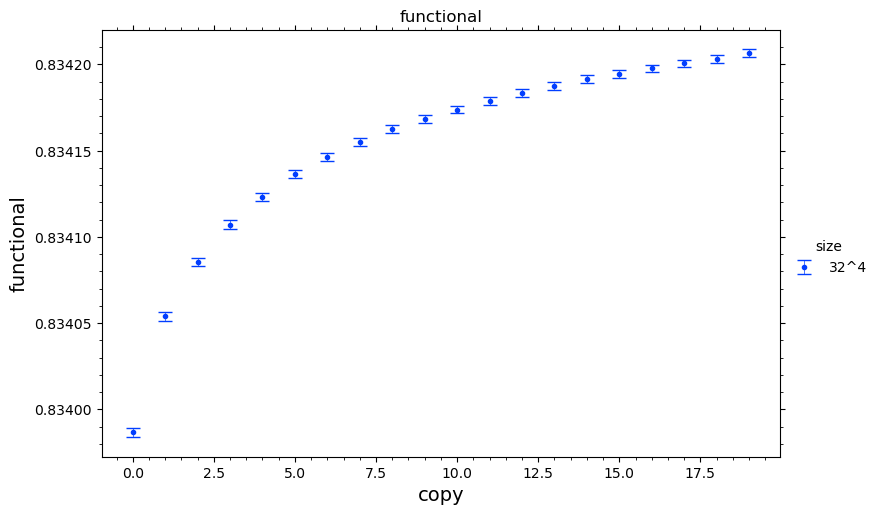

In [9]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.2/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.2, 'size': '32^4', 'steps': 0}}]
df_func = read_functional(paths_functional)
print(df_func)
df_func = fill_funcational_max(df_func, ['size'])
print(df_func)
plots.make_plot(df_func, 'copy', 'functional', 'size', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.0 24^4', True, err='std')

    copy  functional    conf  beta  size  steps
0      0    0.839309     /-1   6.3  36^4      0
1      1    0.839464     /-1   6.3  36^4      0
2      2    0.839329     /-1   6.3  36^4      0
3      3    0.839290     /-1   6.3  36^4      0
4      4    0.839063     /-1   6.3  36^4      0
..   ...         ...     ...   ...   ...    ...
15    15    0.839161  /-2134   6.3  36^4      0
16    16    0.839184  /-2134   6.3  36^4      0
17    17    0.839228  /-2134   6.3  36^4      0
18    18    0.839366  /-2134   6.3  36^4      0
19    19    0.839325  /-2134   6.3  36^4      0

[42680 rows x 6 columns]
    size  functional       std  copy
0   36^4    0.839295  0.000003     0
1   36^4    0.839356  0.000003     1
2   36^4    0.839386  0.000003     2
3   36^4    0.839404  0.000003     3
4   36^4    0.839417  0.000003     4
5   36^4    0.839427  0.000003     5
6   36^4    0.839435  0.000003     6
7   36^4    0.839443  0.000003     7
8   36^4    0.839450  0.000003     8
9   36^4    0.839455  0.0000

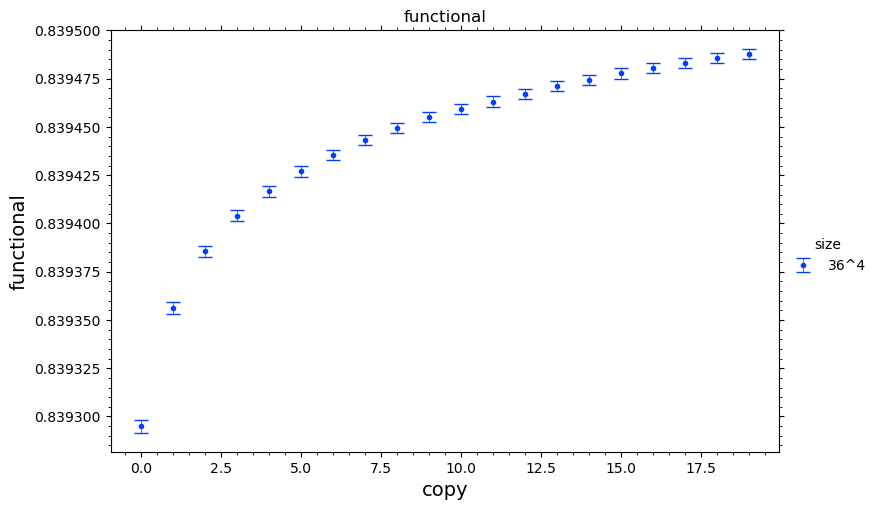

In [10]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.3/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.3, 'size': '36^4', 'steps': 0}}]
df_func = read_functional(paths_functional)
print(df_func)
df_func = fill_funcational_max(df_func, ['size'])
print(df_func)
plots.make_plot(df_func, 'copy', 'functional', 'size', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.0 24^4', True, err='std')

    copy  functional     conf  beta  size  steps
0      0    0.828168     s1-1   6.1  36^4      0
1      1    0.828194     s1-1   6.1  36^4      0
2      2    0.828172     s1-1   6.1  36^4      0
3      3    0.828182     s1-1   6.1  36^4      0
4      4    0.828186     s1-1   6.1  36^4      0
..   ...         ...      ...   ...   ...    ...
5      5    0.827932  s4-5000   6.1  36^4      0
6      6    0.828164  s4-5000   6.1  36^4      0
7      7    0.828011  s4-5000   6.1  36^4      0
8      8    0.827975  s4-5000   6.1  36^4      0
9      9    0.827996  s4-5000   6.1  36^4      0

[120990 rows x 6 columns]
   size  functional       std  copy
0  36^4    0.828116  0.000001     0
1  36^4    0.828165  0.000001     1
2  36^4    0.828188  0.000001     2
3  36^4    0.828204  0.000001     3
4  36^4    0.828215  0.000001     4
5  36^4    0.828224  0.000001     5
6  36^4    0.828232  0.000001     6
7  36^4    0.828238  0.000001     7
8  36^4    0.828243  0.000001     8
9  36^4    0.828247  0.00

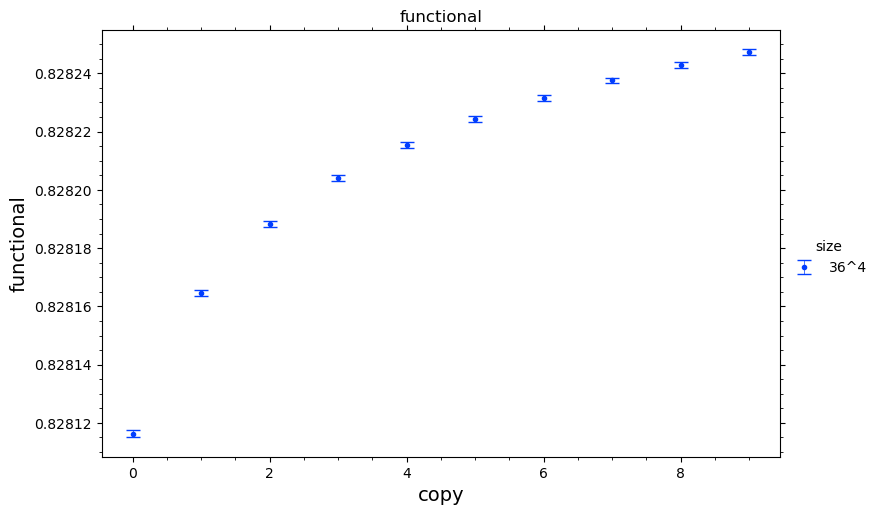

In [13]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's2'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s3/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's3'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s4/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's4'}]
df_func = read_functional(paths_functional)
print(df_func)
df_func = fill_funcational_max(df_func, ['size'])
print(df_func)
plots.make_plot(df_func, 'copy', 'functional', 'size', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.0 24^4', True, err='std')

    copy  functional     conf  beta     size  steps
0    0.0    0.761191     s1-1   6.2  32^3x64    500
1    1.0    0.761183     s1-1   6.2  32^3x64    500
2    2.0    0.761188     s1-1   6.2  32^3x64    500
3    3.0    0.761170     s1-1   6.2  32^3x64    500
0    0.0    0.834832     s1-2   6.2  32^3x64    500
..   ...         ...      ...   ...      ...    ...
3    3.0    0.834961  s2-2118   6.2  32^3x64    500
0    0.0    0.834933  s2-2119   6.2  32^3x64    500
1    1.0    0.834875  s2-2119   6.2  32^3x64    500
2    2.0    0.834965  s2-2119   6.2  32^3x64    500
3    3.0    0.834952  s2-2119   6.2  32^3x64    500

[16916 rows x 6 columns]
      beta     size  steps  functional       std  copy
0      6.0     16^4      0    0.821653  0.000016     0
1      6.0     16^4     10    0.822180  0.000014     0
2      6.0     16^4    100    0.822717  0.000014     0
3      6.0     24^4      0    0.821516  0.000004     0
4      6.0     24^4     10    0.822208  0.000008     0
...    ...      ... 

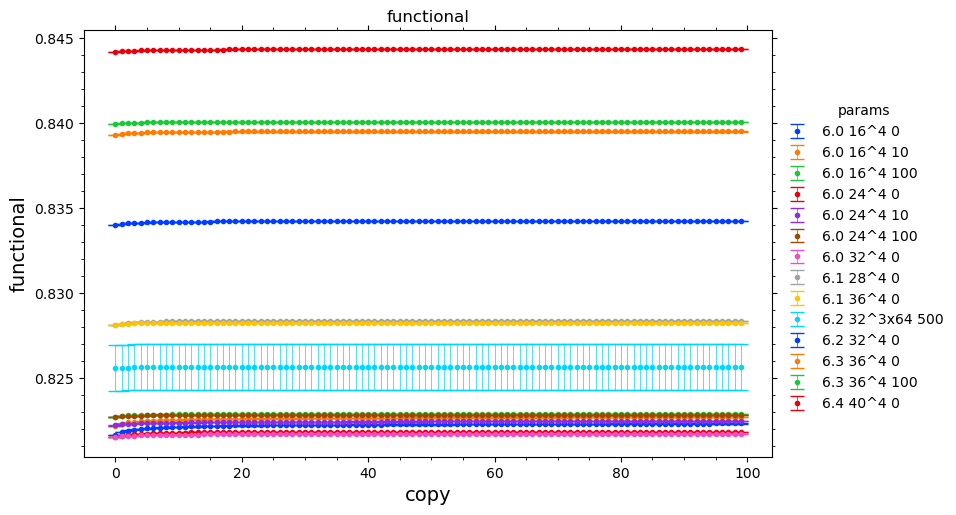

In [11]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/16^4/beta6.0/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '16^4', 'steps': 0}, 'padding': 5},
                    {'path': '../../data/mag/functional/su3/gluodynamics/16^4/beta6.0/steps_0/copies=100/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '16^4', 'steps': 0}, 'padding': 5},
                    {'path': '../../data/mag/functional/su3/gluodynamics/16^4/beta6.0/steps_10/copies=100/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '16^4', 'steps': 10}, 'padding': 5},
                    {'path': '../../data/mag/functional/su3/gluodynamics/16^4/beta6.0/steps_100/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '16^4', 'steps': 100}, 'padding': 5},
                    {'path': '../../data/mag/functional/su3/gluodynamics/16^4/beta6.0/steps_100/copies=100/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '16^4', 'steps': 100}, 'padding': 5},
                    {'path': '../../data/mag/functional/su3/gluodynamics/24^4/beta6.0/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '24^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/24^4/beta6.0/steps_0/copies=100/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '24^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/24^4/beta6.0/steps_10/copies=100/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '24^4', 'steps': 10}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/24^4/beta6.0/steps_100/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '24^4', 'steps': 100}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/24^4/beta6.0/steps_100/copies=100/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '24^4', 'steps': 100}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=20/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32^4', 'steps': 0}, 'chain': 's0'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=20/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32^4', 'steps': 0}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=100/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32^4', 'steps': 0}, 'chain': 's0'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=100/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32^4', 'steps': 0}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/28^4/beta6.1/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.1, 'size': '28^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s1/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s2/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's2'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s3/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's3'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s4/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's4'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.2/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.2, 'size': '32^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^3x64/beta6.2/steps_500/copies=4/s1/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.2, 'size': '32^3x64', 'steps': 500}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^3x64/beta6.2/steps_500/copies=4/s2/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.2, 'size': '32^3x64', 'steps': 500}, 'chain': 's2'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.3/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.3, 'size': '36^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.3/steps_100/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.3, 'size': '36^4', 'steps': 100}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/40^4/beta6.4/steps_0/copies=20/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.4, 'size': '40^4', 'steps': 0}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/40^4/beta6.4/steps_0/copies=20/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.4, 'size': '40^4', 'steps': 0}, 'chain': 's2'}]
df_func = read_functional(paths_functional)
print(df_func[df_func['size']=='32^3x64'])
df_func = fill_funcational_max(df_func, ['beta', 'size', 'steps'])
print(df_func)
df_func['beta'] = df_func['beta'].astype(str)
df_func['steps'] = df_func['steps'].astype(str)
df_func['params'] = df_func['beta'] + ' ' + df_func['size'] + ' ' + df_func['steps']
plots.make_plot(df_func, 'copy', 'functional', 'params', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional beta6.0 24^4', True, err='std')

In [5]:
paths_functional = [{'path': '../../data/mag/functional/su3/gluodynamics/16^4/beta6.0/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '16^4', 'steps': 0}, 'padding': 5},
                    {'path': '../../data/mag/functional/su3/gluodynamics/24^4/beta6.0/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '24^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=20/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32^4', 'steps': 0}, 'chain': 's0'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.0/steps_0/copies=20/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.0, 'size': '32^4', 'steps': 0}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/28^4/beta6.1/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.1, 'size': '28^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s1/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s2/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's2'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s3/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's3'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.1/steps_0/copies=10/s4/functional', 'conf_range': (1, 6000), 'parameters': {'beta': 6.1, 'size': '36^4', 'steps': 0}, 'chain': 's4'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/32^4/beta6.2/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.2, 'size': '32^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/36^4/beta6.3/steps_0/copies=20/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.3, 'size': '36^4', 'steps': 0}},
                    {'path': '../../data/mag/functional/su3/gluodynamics/40^4/beta6.4/steps_0/copies=20/s1/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.4, 'size': '40^4', 'steps': 0}, 'chain': 's1'},
                    {'path': '../../data/mag/functional/su3/gluodynamics/40^4/beta6.4/steps_0/copies=20/s2/functional', 'conf_range': (1, 5000), 'parameters': {'beta': 6.4, 'size': '40^4', 'steps': 0}, 'chain': 's2'}]
df_func = read_functional(paths_functional)
df_func = fill_funcational_max(df_func, ['beta', 'size', 'steps'])
df_func = df_func[df_func['copy'] == 0]
df_func = df_func.drop('copy', axis = 1)
df_func = df_func.drop('steps', axis = 1)
df_func['functional'] = (1 - df_func['functional']) * 3/2
df_func['std'] = df_func['std'] * 3/2
df_func['size'] = '$' + df_func['size'] + '$'
print(df_func)
csv_path = '../../result/mag/su3/functional'
try:
    os.makedirs(csv_path)
except:
    pass
df_func.to_csv(f'{csv_path}/functional_random_copy.csv', sep=',', index=False)
# plots.make_plot(df_func, 'copy', 'functional', 'params', 'copy', 'functional', 'functional', '../../result/mag/su3/functional', 'functional random copy', True, err='std')

   beta    size  functional       std
0   6.0  $16^4$    0.267833  0.000025
1   6.0  $24^4$    0.267758  0.000006
2   6.0  $32^4$    0.267745  0.000004
3   6.1  $28^4$    0.257835  0.000005
4   6.1  $36^4$    0.257826  0.000002
5   6.2  $32^4$    0.249020  0.000004
6   6.3  $36^4$    0.241058  0.000005
7   6.4  $40^4$    0.233791  0.000004


In [ ]:
data_ensembles = [{'beta': 6.0, 'size': '16^4', 'conf number': 1342, 'steps': [0, 0, 10, 100, 100], 'copies': [20, 100, 100, 20, 100], 'copy saved': ['best of n', 'each', 'each', 'the best', 'each']},
                {'beta': 6.0, 'size': '24^4', 'conf number': 5000, 'steps': [0, 0, 10, 100, 100], 'copies': [20, 100, 100, 20, 100], 'copy saved': ['best of n', 'each', 'each', 'the best', 'each']},
                {'beta': 6.0, 'size': '32^4', 'conf number': 4000, 'steps': [0, 0], 'copies': [20, 100], 'copy saved': ['best of n', 'each']},
                {'beta': 6.1, 'size': '28^4', 'conf number': 5000, 'steps': [0], 'copies': [20], 'copy saved': ['best of n']},
                {'beta': 6.1, 'size': '36^4', 'conf number': 14000, 'steps': [0], 'copies': [10], 'copy saved': ['best of n']},
                {'beta': 6.2, 'size': '32^4', 'conf number': 3800, 'steps': [0], 'copies': [20], 'copy saved': ['best of n']},
                {'beta': 6.2, 'size': '32^3x64', 'conf number': 4200, 'steps': [500], 'copies': [4], 'copy saved': ['the best']},
                {'beta': 6.3, 'size': '36^4', 'conf number': 2100, 'steps': [0, 100], 'copies': [20, 20], 'copy saved': ['best of n', 'the best']},
                {'beta': 6.4, 'size': '40^4', 'conf number': 2000, 'steps': [0], 'copies': [20], 'copy saved': ['best of n']}]
betas = []
sizes = []
conf_number = []
steps = []
copies = []
copy_saved = []
for ensemble in data_ensembles:
    for i in range(len(ensemble['steps'])):
        betas.append(ensemble['beta'])
        sizes.append(ensemble['size'])
        conf_number.append(ensemble['conf number'])
        steps.append(ensemble['steps'][i])
        copies.append(ensemble['copies'][i])
        copy_saved.append(ensemble['copy saved'][i])
df_ensemble = pd.DataFrame({'beta': betas, 'size': sizes, 'conf number': conf_number,
                            'steps': steps, 'copies': copies, 'copy saved': copy_saved})
print(df_ensemble)
csv_path = '../../result/ensemble_data/su3/gluodynamics'
try:
    os.makedirs(csv_path)
except:
    pass
df_ensemble.to_csv(f'{csv_path}/ensemble_data.csv', sep=',', index=False)

    beta     size  conf number  steps  copies copy saved
0    6.0     16^4         1342      0      20  best of n
1    6.0     16^4         1342      0     100       each
2    6.0     16^4         1342     10     100       each
3    6.0     16^4         1342    100      20   the best
4    6.0     16^4         1342    100     100       each
5    6.0     24^4         5000      0      20  best of n
6    6.0     24^4         5000      0     100       each
7    6.0     24^4         5000     10     100       each
8    6.0     24^4         5000    100      20   the best
9    6.0     24^4         5000    100     100       each
10   6.0     32^4         4000      0      20  best of n
11   6.0     32^4         4000      0     100       each
12   6.1     28^4         5000      0      20  best of n
13   6.1     36^4        14000      0      10  best of n
14   6.2     32^4         3800      0      20  best of n
15   6.2  32^3x64         4200    500       4   the best
16   6.3     36^4         2100 